In [59]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [60]:
import sys
from pathlib import Path

PROJECT_ROOT = str(Path.cwd().parent)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)



In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from pathlib import Path
from src.config import add_borough_dummies


pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")

FIG_DIR = Path("../reports/figures")
METRICS_DIR = Path("../reports/metrics")
MODEL_DIR = Path("../models")
OUT_DIR = Path("../data/processed")

FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [62]:
df = pd.read_csv("../data/processed/train.csv")

In [63]:
CRIME_COLS = [
    "murder", "rape", "robbery", "felony_assault",
    "burglary", "grand_larceny", "grand_larceny_auto"
]

def add_crime_rates(df, per=1000):
    total_units = df["avg_unitstotal"] * df["num_bbls"]
    total_units = total_units.replace(0, np.nan)  # avoid divide-by-zero
    for c in CRIME_COLS:
        df[f"{c}_rate"] = df[c] / (total_units / per)
    return df

df = add_crime_rates(df)
df[[f"{c}_rate" for c in CRIME_COLS]].describe()


BOROUGH_CODES = ["BX", "BK", "MN", "QN", "SI"]

df["borough"] = df["nta2020"].str[:2]
df["borough"] = pd.Categorical(df["borough"], categories=BOROUGH_CODES)
dummies = pd.get_dummies(df["borough"], prefix="borough", drop_first=True)
df = pd.concat([df, dummies], axis=1)

df["borough"].value_counts()

borough
BK    52
QN    48
BX    34
MN    31
SI    10
Name: count, dtype: int64

In [64]:
TARGET = "log_median_rent"

EXCLUDE_COLS = [
    "nta2020",
    "ntaname",
    "median_monthly_rent",
    "avg_monthly_rent",
    "rent_num_properties",
    "school_count",
    "avg_ats",
    "borough",
    *CRIME_COLS,
    TARGET
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
y = df[TARGET]

# Drop all-NaN feature columns (safety)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

feature_cols = X.columns.tolist()
print("Rows:", len(df), "Features:", len(feature_cols))

Rows: 175 Features: 22


In [65]:
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": randint(3, 30),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": uniform(0.3, 0.7),   # 0.3–1.0
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X, y)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV RMSE (log):", -rf_search.best_score_)
rf_pipe = rf_search.best_estimator_

Best RF params: {'model__max_depth': 6, 'model__max_features': 0.42939811886786894, 'model__min_samples_leaf': 2, 'model__n_estimators': 929}
Best RF CV RMSE (log): 0.2568295417375296


In [66]:
hgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

hgb_param_dist = {
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 10),
    "model__max_leaf_nodes": randint(15, 63),
    "model__min_samples_leaf": randint(5, 30),
    "model__l2_regularization": uniform(0.0, 1.0),
}

hgb_search = RandomizedSearchCV(
    hgb_pipe,
    param_distributions=hgb_param_dist,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
hgb_search.fit(X, y)

print("Best HGB params:", hgb_search.best_params_)
print("Best HGB CV RMSE (log):", -hgb_search.best_score_)

hgb_pipe = hgb_search.best_estimator_  # lock in tuned version for everything downstream

Best HGB params: {'model__l2_regularization': 0.4722149251619493, 'model__learning_rate': 0.03272290672827732, 'model__max_depth': 7, 'model__max_leaf_nodes': 17, 'model__min_samples_leaf': 5}
Best HGB CV RMSE (log): 0.2567764069511735


In [67]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate(model, X, y, name):
    rmses = []
    maes = []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmses.append(rmse(y_va, pred))
        maes.append(mean_absolute_error(y_va, pred))
    print(f"{name} CV RMSE (log): {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"{name} CV MAE  (log): {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    return np.mean(rmses), np.mean(maes)

rf_cv_rmse, rf_cv_mae = cv_evaluate(rf_pipe, X, y, "RandomForest")
hgb_cv_rmse, hgb_cv_mae = cv_evaluate(hgb_pipe, X, y, "HistGB")


RandomForest CV RMSE (log): 0.2568 ± 0.0392
RandomForest CV MAE  (log): 0.1938 ± 0.0292
HistGB CV RMSE (log): 0.2568 ± 0.0516
HistGB CV MAE  (log): 0.1960 ± 0.0336


In [68]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

lgbm_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LGBMRegressor(random_state=42, verbosity=-1))
])

xgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(random_state=42))
])

lgbm_param_dist = {
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 10),
    "model__num_leaves": randint(15, 63),
    "model__min_child_samples": randint(5, 30),
    "model__reg_lambda": uniform(0.0, 1.0),
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe,
    param_distributions=lgbm_param_dist,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
lgbm_search.fit(X, y)
print("Best LightGBM params:", lgbm_search.best_params_)
print("Best LightGBM CV RMSE (log):", -lgbm_search.best_score_)
lgbm_pipe = lgbm_search.best_estimator_

xgb_param_dist = {
    "model__learning_rate": uniform(0.01, 0.19),
    "model__max_depth": randint(2, 10),
    "model__min_child_weight": randint(1, 10),
    "model__subsample": uniform(0.6, 0.4),      # 0.6–1.0
    "model__reg_lambda": uniform(0.0, 2.0),
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X, y)
print("Best XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV RMSE (log):", -xgb_search.best_score_)
xgb_pipe = xgb_search.best_estimator_

lgbm_cv_rmse, lgbm_cv_mae = cv_evaluate(lgbm_pipe, X, y, "LightGBM")
xgb_cv_rmse, xgb_cv_mae = cv_evaluate(xgb_pipe, X, y, "XGBoost")

Best LightGBM params: {'model__learning_rate': 0.04723674385963759, 'model__max_depth': 2, 'model__min_child_samples': 12, 'model__num_leaves': 35, 'model__reg_lambda': 0.388677289689482}
Best LightGBM CV RMSE (log): 0.261138035088553
Best XGBoost params: {'model__learning_rate': 0.030043909367751413, 'model__max_depth': 5, 'model__min_child_weight': 4, 'model__reg_lambda': 1.7851179969799555, 'model__subsample': 0.8157368967662603}
Best XGBoost CV RMSE (log): 0.25420172784974965
LightGBM CV RMSE (log): 0.2611 ± 0.0458
LightGBM CV MAE  (log): 0.2010 ± 0.0358
XGBoost CV RMSE (log): 0.2542 ± 0.0416
XGBoost CV MAE  (log): 0.1904 ± 0.0294


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

candidates = {
    "RandomForest": (rf_pipe, rf_cv_rmse),
    "HistGB": (hgb_pipe, hgb_cv_rmse),
    "LightGBM": (lgbm_pipe, lgbm_cv_rmse),
    "XGBoost": (xgb_pipe, xgb_cv_rmse),
}
final_name = min(candidates, key=lambda k: candidates[k][1])
final_model = candidates[final_name][0]

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

test_rmse_log = rmse(y_test, y_pred)
test_mae_log = mean_absolute_error(y_test, y_pred)
test_mae_dollars = np.mean(np.abs(np.exp(y_test) - np.exp(y_pred)))

print("Final model:", final_name)
print("Test RMSE (log):", test_rmse_log)
print("Test MAE (log):", test_mae_log)
print("Test MAE ($):", test_mae_dollars)

Final model: XGBoost
Test RMSE (log): 0.20301016190481322
Test MAE (log): 0.16400014158495965
Test MAE ($): 416.98284978150707


In [70]:
from sklearn.ensemble import HistGradientBoostingRegressor as HGB

LOWER_MODEL_PATH = MODEL_DIR / "03_final_model_q10.joblib"
UPPER_MODEL_PATH = MODEL_DIR / "03_final_model_q90.joblib"

def make_quantile_pipe(quantile):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HGB(
            loss="quantile",
            quantile=quantile,
            random_state=42,
            learning_rate=0.05,
            max_depth=6,
            max_leaf_nodes=31,
            min_samples_leaf=10
        ))
    ])

lower_pipe = make_quantile_pipe(0.10)
upper_pipe = make_quantile_pipe(0.90)

lower_pipe.fit(X_train, y_train)
upper_pipe.fit(X_train, y_train)

joblib.dump(lower_pipe, LOWER_MODEL_PATH)
joblib.dump(upper_pipe, UPPER_MODEL_PATH)

['../models/03_final_model_q90.joblib']

In [71]:
y_pred_low = lower_pipe.predict(X_test)
y_pred_high = upper_pipe.predict(X_test)

interval_df = pd.DataFrame({
    "actual_rent": np.exp(y_test.values),
    "pred_rent": np.exp(y_pred),
    "pred_low": np.exp(y_pred_low),
    "pred_high": np.exp(y_pred_high),
})

# Enforce correct ordering in case of quantile crossing
interval_df["pred_low"] = interval_df[["pred_low", "pred_rent"]].min(axis=1)
interval_df["pred_high"] = interval_df[["pred_high", "pred_rent"]].max(axis=1)

interval_df["interval_width"] = interval_df["pred_high"] - interval_df["pred_low"]

interval_df.sort_values("actual_rent", ascending=False)
interval_df[["actual_rent", "interval_width"]].corr()

,actual_rent,interval_width
actual_rent,1.000000,0.803858
interval_width,0.803858,1.000000


In [72]:
n_crossed = ((interval_df["pred_high"] < interval_df["pred_rent"]) | 
             (interval_df["pred_low"] > interval_df["pred_rent"])).sum()
print(f"{n_crossed} / {len(interval_df)} test rows had quantile crossing")

0 / 35 test rows had quantile crossing


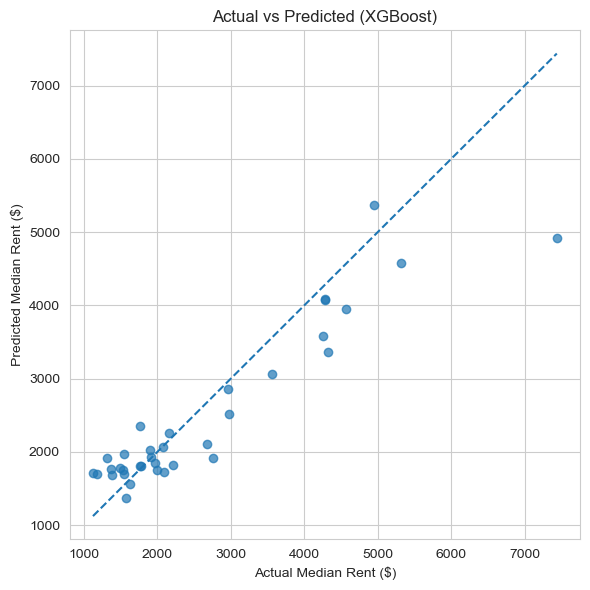

In [73]:
y_true_d = np.exp(y_test)
y_pred_d = np.exp(y_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_true_d, y_pred_d, alpha=0.7)
mn = min(y_true_d.min(), y_pred_d.min())
mx = max(y_true_d.max(), y_pred_d.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual Median Rent ($)")
plt.ylabel("Predicted Median Rent ($)")
plt.title(f"Actual vs Predicted ({final_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_actual_vs_pred.png", dpi=200)
plt.show()


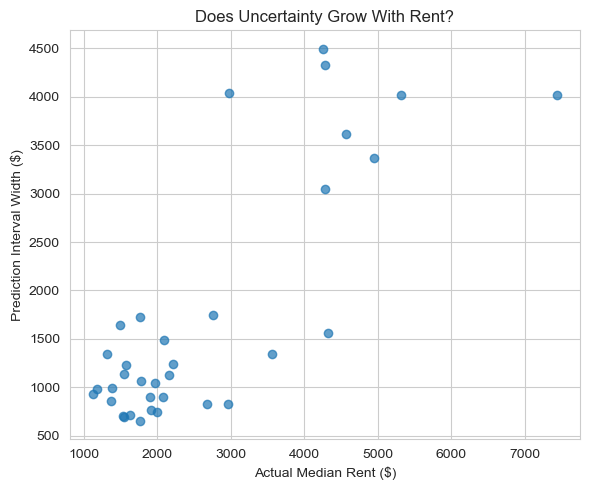

In [74]:
plt.figure(figsize=(6, 5))
plt.scatter(interval_df["actual_rent"], interval_df["interval_width"], alpha=0.7)
plt.xlabel("Actual Median Rent ($)")
plt.ylabel("Prediction Interval Width ($)")
plt.title("Does Uncertainty Grow With Rent?")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_interval_width_vs_rent.png", dpi=200)
plt.show()

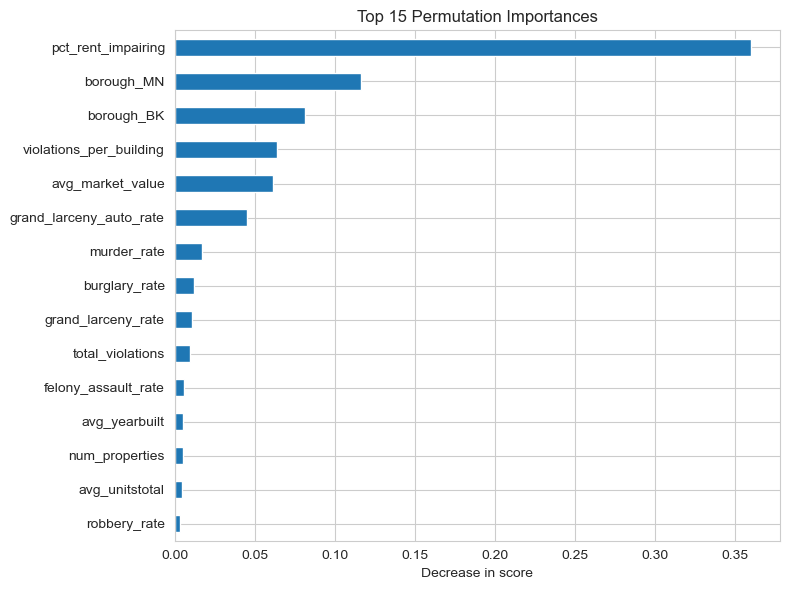

pct_rent_impairing         0.359914
borough_MN                 0.116523
borough_BK                 0.081440
violations_per_building    0.064108
avg_market_value           0.061588
grand_larceny_auto_rate    0.045498
murder_rate                0.016838
burglary_rate              0.012384
grand_larceny_rate         0.010982
total_violations           0.009520
felony_assault_rate        0.005990
avg_yearbuilt              0.005379
num_properties             0.005132
avg_unitstotal             0.004668
robbery_rate               0.003427
avg_unitsres               0.003346
borough_SI                 0.003292
num_bbls                   0.002727
borough_QN                 0.000138
rape_rate                 -0.000117
dtype: float64

In [75]:
if final_name == "RandomForest":
    model = final_model.named_steps["model"]
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_feature_importance.png", dpi=200)
    plt.show()
else:
    from sklearn.inspection import permutation_importance

    # Use a smaller sample for speed
    r = permutation_importance(final_model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
    importances = pd.Series(r.importances_mean, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 Permutation Importances")
    plt.xlabel("Decrease in score")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_feature_importance.png", dpi=200)
    plt.show()

importances.head(20)


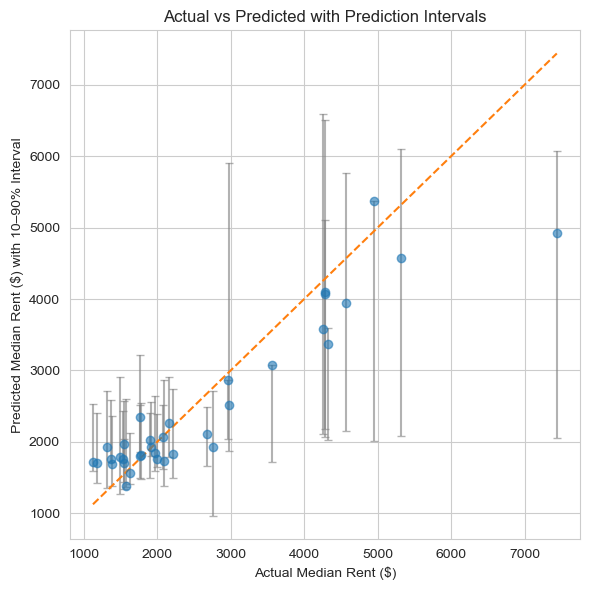

In [76]:
plt.figure(figsize=(6, 6))
plt.errorbar(
    interval_df["actual_rent"], interval_df["pred_rent"],
    yerr=[interval_df["pred_rent"] - interval_df["pred_low"],
          interval_df["pred_high"] - interval_df["pred_rent"]],
    fmt="o", alpha=0.6, ecolor="gray", capsize=3
)
mn = interval_df[["actual_rent", "pred_rent"]].min().min()
mx = interval_df[["actual_rent", "pred_rent"]].max().max()
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Actual Median Rent ($)")
plt.ylabel("Predicted Median Rent ($) with 10–90% Interval")
plt.title("Actual vs Predicted with Prediction Intervals")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_actual_vs_pred_with_intervals.png", dpi=200)
plt.show()

In [77]:
# Save model
joblib.dump(final_model, MODEL_DIR / "03_final_model.joblib")

# Save metrics
metrics = {
    "final_model": final_name,
    "rf_cv_rmse_log": float(rf_cv_rmse),
    "hgb_cv_rmse_log": float(hgb_cv_rmse),
    "lgbm_cv_rmse_log": float(lgbm_cv_rmse),
    "xgb_cv_rmse_log": float(xgb_cv_rmse),
    "test_rmse_log": float(test_rmse_log),
    "test_mae_log": float(test_mae_log),
    "test_mae_dollars": float(test_mae_dollars),
    "n_rows": int(len(df)),
    "n_features": int(len(feature_cols)),
    "top_features": importances.head(10).to_dict()
}

pd.Series(metrics).to_json(METRICS_DIR / "03_metrics.json", indent=2)

# Save test predictions
pred_df = pd.DataFrame({
    "y_true_log": y_test.values,
    "y_pred_log": y_pred,
    "y_true": y_true_d.values,
    "y_pred": y_pred_d
})

pred_df.to_csv(OUT_DIR / "03_test_predictions.csv", index=False)

print("Saved:",
      "\n- model ->", MODEL_DIR / "03_final_model.joblib",
      "\n- metrics ->", METRICS_DIR / "03_metrics.json",
      "\n- figures ->", FIG_DIR,
      "\n- predictions ->", OUT_DIR / "03_test_predictions.csv")


Saved: 
- model -> ../models/03_final_model.joblib 
- metrics -> ../reports/metrics/03_metrics.json 
- figures -> ../reports/figures 
- predictions -> ../data/processed/03_test_predictions.csv
